# Домашнее задание №5
## Звёзды | Солнечные пятна | Баскетболисты NBA

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['axes.grid'] = True

---
# 1. Звёзды

In [23]:
stars = pd.read_csv('stars.csv')
stars.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [24]:
stars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


### 1.1 Нормализация столбца `Star color`

In [25]:
def normalize_color(c):
    c = str(c).strip().lower()
    c = c.replace('-', ' ').replace('_', ' ')
    return ' '.join(w.capitalize() for w in c.split())

stars['Star color'] = stars['Star color'].apply(normalize_color)
print(stars['Star color'].value_counts())

Star color
Red                   112
Blue                   56
Blue White             41
White                  10
Yellow White            8
Yellowish White         3
Yellowish               3
Whitish                 2
Orange                  2
Pale Yellow Orange      1
White Yellow            1
Orange Red              1
Name: count, dtype: int64


### 1.2 Добавление строкового столбца типа звезды

In [26]:
type_map = {
    0: 'Red Dwarf',
    1: 'Brown Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Super Giants',
    5: 'Hyper Giants'
}
stars['Star type name'] = stars['Star type'].map(type_map)
stars[['Star type', 'Star type name']].value_counts().sort_index()

,,count
Star type,Star type name,
0,Red Dwarf,40
1,Brown Dwarf,40
2,White Dwarf,40
3,Main Sequence,40
4,Super Giants,40
5,Hyper Giants,40


### 1.3 Добавление числового столбца спектрального класса

In [27]:
spectral_map = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
stars['Spectral Class num'] = stars['Spectral Class'].map(spectral_map)
stars[['Spectral Class', 'Spectral Class num']].drop_duplicates().sort_values('Spectral Class num')

,Spectral Class,Spectral Class num
30,O,0
20,B,1
21,A,2
22,F,3
118,G,4
91,K,5
0,M,6


### 1.4 Количество звёзд по цвету, типу и спектральному классу

In [28]:
print("По цвету:")
print(stars['Star color'].value_counts(), '\n')
print("По типу:")
print(stars['Star type name'].value_counts(), '\n')
print("По спектральному классу:")
print(stars['Spectral Class'].value_counts().sort_index())

По цвету:
Star color
Red                   112
Blue                   56
Blue White             41
White                  10
Yellow White            8
Yellowish White         3
Yellowish               3
Whitish                 2
Orange                  2
Pale Yellow Orange      1
White Yellow            1
Orange Red              1
Name: count, dtype: int64 

По типу:
Star type name
Red Dwarf        40
Brown Dwarf      40
White Dwarf      40
Main Sequence    40
Super Giants     40
Hyper Giants     40
Name: count, dtype: int64 

По спектральному классу:
Spectral Class
A     19
B     46
F     17
G      1
K      6
M    111
O     40
Name: count, dtype: int64


### 1.5 Статистики абсолютной звёздной величины по типу

                  Min   Mean    Max
Star type name                     
Brown Dwarf     10.12  12.54  14.94
Hyper Giants   -11.92  -9.65  -7.58
Main Sequence   -4.70  -0.37   6.51
Red Dwarf       16.05  17.56  20.06
Super Giants    -7.45  -6.37  -5.24
White Dwarf     10.18  12.58  14.87


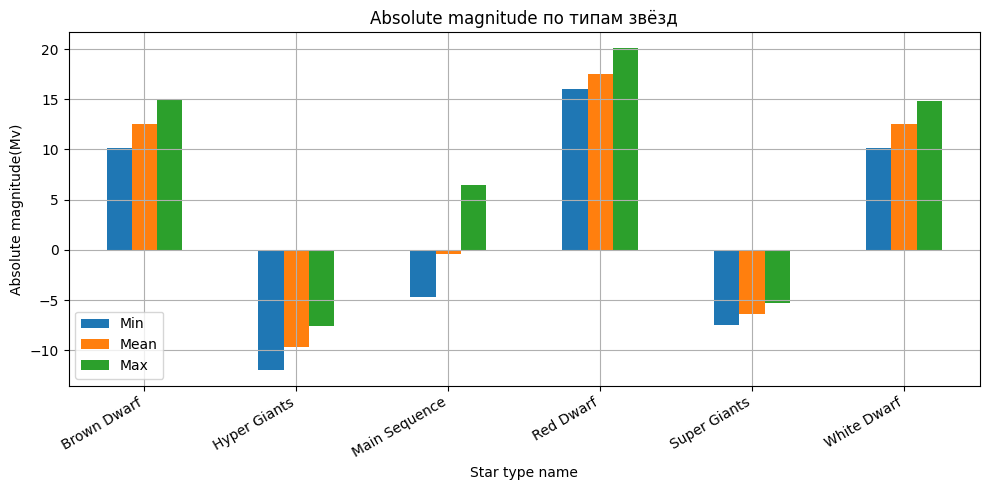

In [29]:
stats_type = stars.groupby('Star type name')['Absolute magnitude(Mv)'].agg(['min','mean','max'])
stats_type.columns = ['Min', 'Mean', 'Max']
print(stats_type.round(2))
stats_type.plot(kind='bar', title='Absolute magnitude по типам звёзд')
plt.ylabel('Absolute magnitude(Mv)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 1.6 Статистики температуры по спектральному классу

                 Min     Mean    Max
Spectral Class                      
A               7723   9842.0  14060
B               9700  19574.0  33750
F               5300   8517.0  14732
G               6850   6850.0   6850
K               4015   4500.0   5112
M               1939   3257.0   3834
O               5752  22294.0  40000


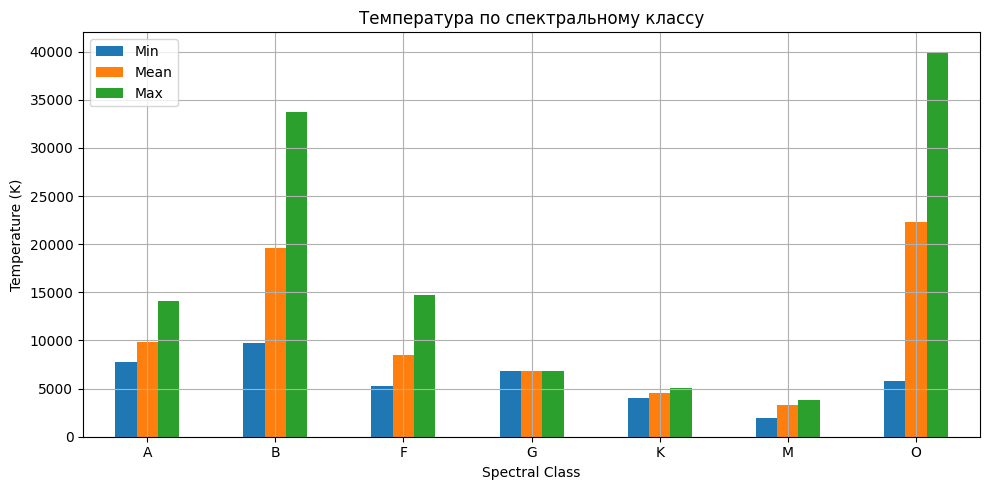

In [30]:
stats_class = stars.groupby('Spectral Class')['Temperature (K)'].agg(['min','mean','max'])
stats_class.columns = ['Min', 'Mean', 'Max']
print(stats_class.round(0))
stats_class.plot(kind='bar', title='Температура по спектральному классу')
plt.ylabel('Temperature (K)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.7 Попарные корреляции числовых столбцов

                        Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  \
Temperature (K)                   1.000             0.393         0.064   
Luminosity(L/Lo)                  0.393             1.000         0.527   
Radius(R/Ro)                      0.064             0.527         1.000   
Absolute magnitude(Mv)           -0.420            -0.693        -0.609   
Star type                         0.411             0.677         0.661   
Spectral Class num               -0.817            -0.347         0.061   

                        Absolute magnitude(Mv)  Star type  Spectral Class num  
Temperature (K)                         -0.420      0.411              -0.817  
Luminosity(L/Lo)                        -0.693      0.677              -0.347  
Radius(R/Ro)                            -0.609      0.661               0.061  
Absolute magnitude(Mv)                   1.000     -0.955               0.415  
Star type                               -0.955      1.000              -0.

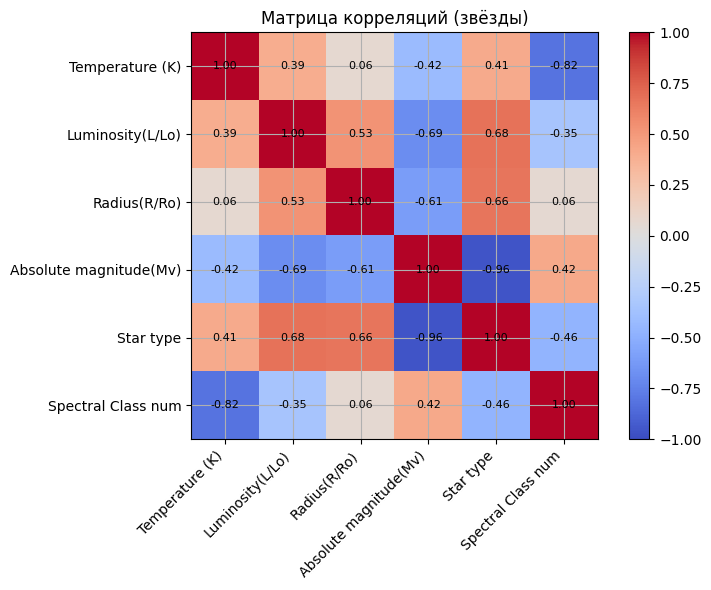

In [31]:
num_cols = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
            'Absolute magnitude(Mv)', 'Star type', 'Spectral Class num']
corr = stars[num_cols].corr()
print(corr.round(3))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Матрица корреляций (звёзды)')
plt.tight_layout()
plt.show()

---
# 2. Солнечные пятна

In [40]:
sunspot = pd.read_csv('sunspot.csv', sep=';', na_values=-1)
sunspot.head()

,Year,Month,Day,Number of Sunspots,Standard Deviation,Observations
0,1818,1,1,NaN,NaN,0
1,1818,1,2,NaN,NaN,0
2,1818,1,3,NaN,NaN,0
3,1818,1,4,NaN,NaN,0
4,1818,1,5,NaN,NaN,0


### 2.1 Создание столбца с полной датой

In [41]:
sunspot['date'] = pd.to_datetime(sunspot[['Year','Month','Day']])
sunspot = sunspot.drop(columns=['Year','Month','Day'])
sunspot.head()

,Number of Sunspots,Standard Deviation,Observations,date
0,NaN,NaN,0,1818-01-01
1,NaN,NaN,0,1818-01-02
2,NaN,NaN,0,1818-01-03
3,NaN,NaN,0,1818-01-04
4,NaN,NaN,0,1818-01-05


### 2.2 Замена `-1` на `np.nan`

In [42]:
sunspot.replace(-1, np.nan, inplace=True)
print(f"Пропуски: {sunspot.isna().sum().to_dict()}")
sunspot.head()

Пропуски: {'Number of Sunspots': 3247, 'Standard Deviation': 3247, 'Observations': 0, 'date': 0}


,Number of Sunspots,Standard Deviation,Observations,date
0,NaN,NaN,0,1818-01-01
1,NaN,NaN,0,1818-01-02
2,NaN,NaN,0,1818-01-03
3,NaN,NaN,0,1818-01-04
4,NaN,NaN,0,1818-01-05


### 2.3 Годовая статистика: дни с данными и сумма пятен

In [48]:
annual = sunspot.groupby(sunspot['date'].dt.year).agg(
    days_with_data=('Number of Sunspots', 'count'),
    total_spots=('Number of Sunspots', 'sum')
).rename_axis('year')
annual.head(10)

,days_with_data,total_spots
year,,
1818,213,11276.0
1819,249,9595.0
1820,224,5428.0
1821,304,2791.0
1822,353,2208.0
1823,302,658.0
1824,194,2218.0
1825,310,8748.0
1826,320,19165.0


### 2.4 Графики годовой статистики

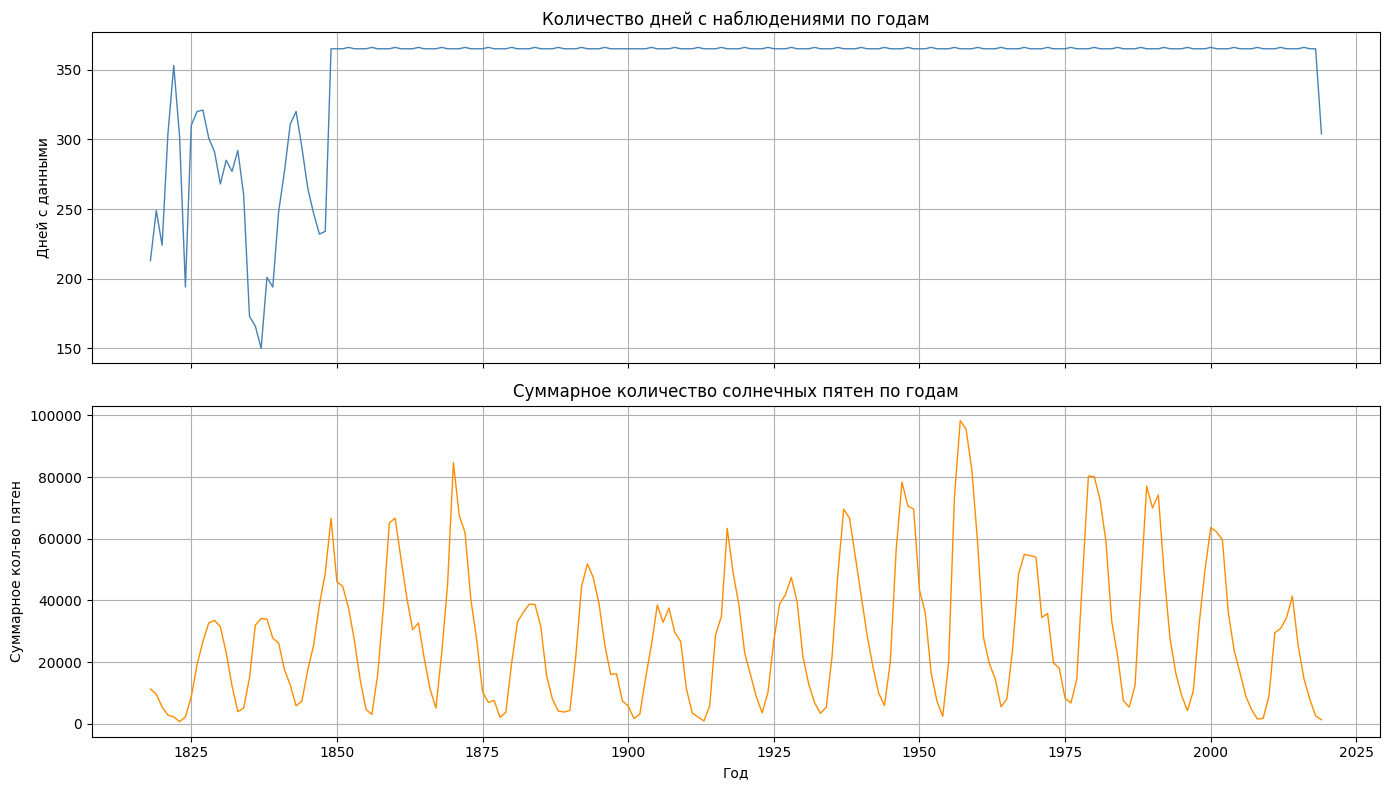

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(annual.index, annual['days_with_data'], color='steelblue', lw=1)
axes[0].set_ylabel('Дней с данными')
axes[0].set_title('Количество дней с наблюдениями по годам')

axes[1].plot(annual.index, annual['total_spots'], color='darkorange', lw=1)
axes[1].set_ylabel('Суммарное кол-во пятен')
axes[1].set_title('Суммарное количество солнечных пятен по годам')
axes[1].set_xlabel('Год')

plt.tight_layout()
plt.show()

### 2.5 Среднее количество пятен по месяцам (данные с 2000 года)

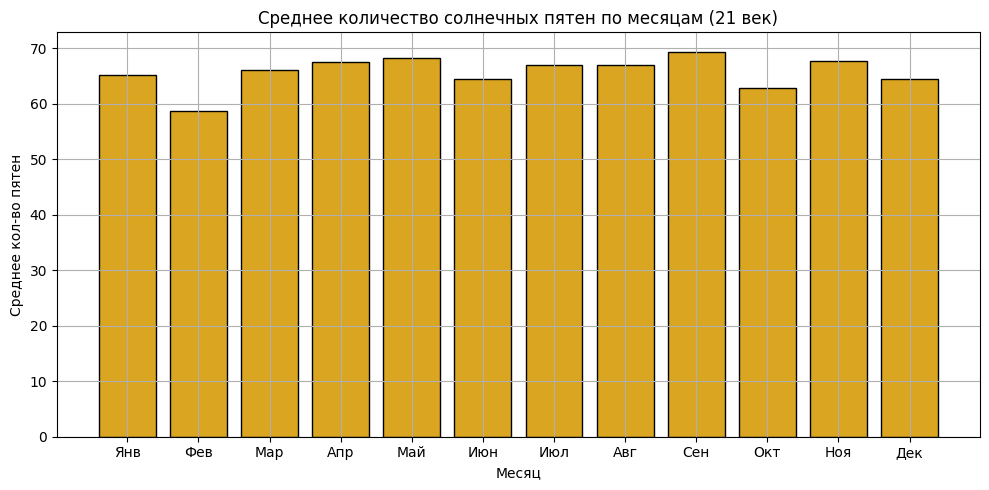

In [51]:
s21 = sunspot[sunspot['date'].dt.year >= 2000].copy()
monthly_avg = s21.groupby(s21['date'].dt.month)['Number of Sunspots'].mean()

month_names = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 13), monthly_avg.values, color='goldenrod', edgecolor='black')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Месяц')
ax.set_ylabel('Среднее кол-во пятен')
ax.set_title('Среднее количество солнечных пятен по месяцам (21 век)')
plt.tight_layout()
plt.show()

---
# 3. Баскетболисты NBA

In [52]:
nba = pd.read_csv('NBA.csv')
nba.head()

,Player Full Name,Birth Date,Year Start,Year End,Position,Height,Wingspan,Weight
0,A.C. Green,04.10.1963,1986,2001,F-C,205.7,NaN,220.0
1,A.J. Bramlett,10.01.1977,2000,2000,C,208.3,NaN,227.0
2,A.J. English,11.07.1967,1991,1992,G,190.5,NaN,175.0
3,A.J. Guyton,12.02.1978,2001,2003,G,185.4,192.4,180.0
4,A.J. Hammons,27.08.1992,2017,2017,C,213.4,NaN,260.0


In [53]:
nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4550 entries, 0 to 4549
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player Full Name  4550 non-null   object 
 1   Birth Date        4550 non-null   object 
 2   Year Start        4550 non-null   int64  
 3   Year End          4550 non-null   int64  
 4   Position          4549 non-null   object 
 5   Height            4550 non-null   float64
 6   Wingspan          757 non-null    float64
 7   Weight            4544 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 284.5+ KB


### 3.1 Перевод веса из фунтов в килограммы

In [54]:
nba['Weight_kg'] = nba['Weight'] * 0.45359237
nba['Weight_kg'] = nba['Weight_kg'].round(2)
nba[['Player Full Name','Weight','Weight_kg']].head()

,Player Full Name,Weight,Weight_kg
0,A.C. Green,220.0,99.79
1,A.J. Bramlett,227.0,102.97
2,A.J. English,175.0,79.38
3,A.J. Guyton,180.0,81.65
4,A.J. Hammons,260.0,117.93


### 3.2 Самый высокий и самый низкий игрок

In [55]:
tallest = nba.loc[nba['Height'].idxmax()]
shortest = nba.loc[nba['Height'].idxmin()]
print(f"Самый высокий: {tallest['Player Full Name']} — {tallest['Height']} см")
print(f"Самый низкий:  {shortest['Player Full Name']} — {shortest['Height']} см")

Самый высокий: Gheorghe Muresan — 231.1 см
Самый низкий:  George Karl — 0.0 см


### 3.3 Самый лёгкий и самый тяжёлый игрок

In [56]:
heaviest = nba.loc[nba['Weight_kg'].idxmax()]
lightest  = nba.loc[nba['Weight_kg'].idxmin()]
print(f"Самый тяжёлый: {heaviest['Player Full Name']} — {heaviest['Weight_kg']:.1f} кг")
print(f"Самый лёгкий:  {lightest['Player Full Name']}  — {lightest['Weight_kg']:.1f} кг")

Самый тяжёлый: Sim Bhullar — 163.3 кг
Самый лёгкий:  Penny Early  — 51.7 кг


### 3.4 Самый маленький и самый большой размах рук

In [57]:
max_wing = nba.loc[nba['Wingspan'].idxmax()]
min_wing  = nba.loc[nba['Wingspan'].idxmin()]
print(f"Макс. размах: {max_wing['Player Full Name']} — {max_wing['Wingspan']} см")
print(f"Мин. размах:  {min_wing['Player Full Name']} — {min_wing['Wingspan']} см")

Макс. размах: Mouhamed Sene — 235.0 см
Мин. размах:  Andris Biedrins — 0.0 см


### 3.5 Корреляции: рост, вес, размах рук; диаграмма рассеяния

Корреляции:
           Height  Weight_kg  Wingspan
Height      1.000      0.803     0.572
Weight_kg   0.803      1.000     0.532
Wingspan    0.572      0.532     1.000


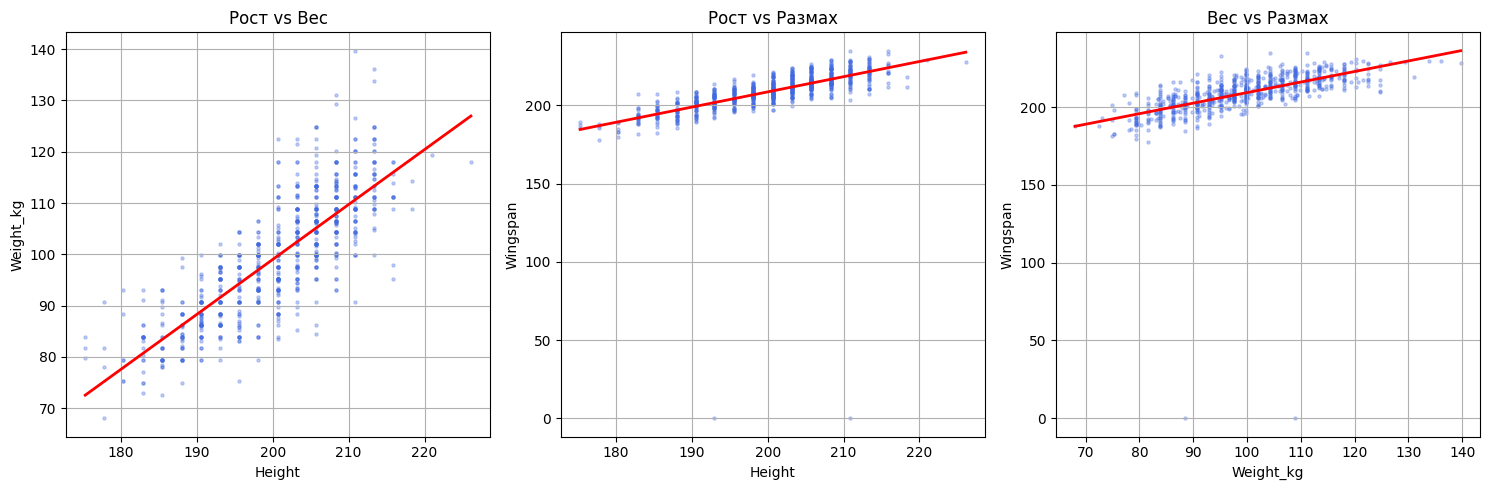

In [58]:
phys = nba[['Height', 'Weight_kg', 'Wingspan']].dropna()
print("Корреляции:")
print(phys.corr().round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [('Height','Weight_kg','Рост vs Вес'),
         ('Height','Wingspan','Рост vs Размах'),
         ('Weight_kg','Wingspan','Вес vs Размах')]
for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(phys[x], phys[y], alpha=0.3, s=5, color='royalblue')
    # Linear regression
    m, b = np.polyfit(phys[x], phys[y], 1)
    xs = np.linspace(phys[x].min(), phys[x].max(), 100)
    ax.plot(xs, m*xs + b, color='red', lw=2)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(title)
plt.tight_layout()
plt.show()

### 3.6 Столбец с продолжительностью карьеры

In [59]:
nba['Career Length'] = nba['Year End'] - nba['Year Start']
nba[['Player Full Name','Year Start','Year End','Career Length']].head()

,Player Full Name,Year Start,Year End,Career Length
0,A.C. Green,1986,2001,15
1,A.J. Bramlett,2000,2000,0
2,A.J. English,1991,1992,1
3,A.J. Guyton,2001,2003,2
4,A.J. Hammons,2017,2017,0


### 3.7 Индекс массы тела (ИМТ)

In [60]:
nba['BMI'] = nba['Weight_kg'] / (nba['Height'] / 100) ** 2
nba['BMI'] = nba['BMI'].round(2)
nba[['Player Full Name','Height','Weight_kg','BMI']].head()

,Player Full Name,Height,Weight_kg,BMI
0,A.C. Green,205.7,99.79,23.58
1,A.J. Bramlett,208.3,102.97,23.73
2,A.J. English,190.5,79.38,21.87
3,A.J. Guyton,185.4,81.65,23.75
4,A.J. Hammons,213.4,117.93,25.90


### 3.8 Зависимость показателей от позиции

          Career Length  Height  Weight_kg  Wingspan
Position                                            
C                  4.13  211.33     110.93    219.45
C-F                6.12  206.96     103.87    220.03
F                  3.19  201.55      98.95    213.93
F-C                6.31  204.56     101.57    219.60
F-G                6.05  196.97      92.12    211.18
G                  3.77  189.35      84.77    199.45
G-F                5.20  194.74      89.63    208.93


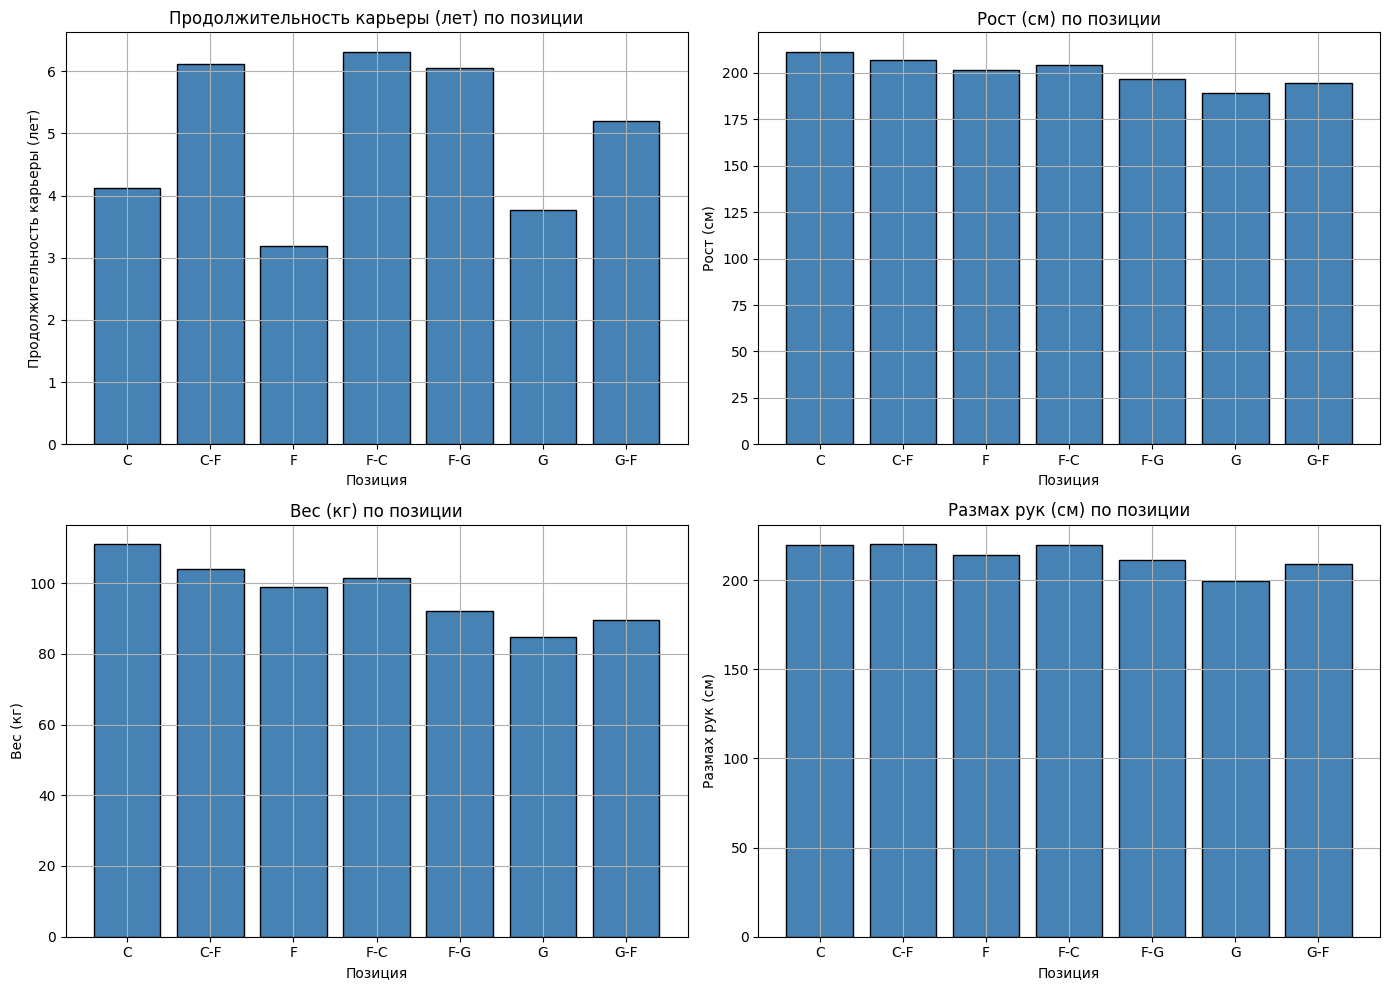

In [61]:
pos_stats = nba.groupby('Position')[['Career Length','Height','Weight_kg','Wingspan']].mean()
print(pos_stats.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [('Career Length','Продолжительность карьеры (лет)'),
           ('Height','Рост (см)'),
           ('Weight_kg','Вес (кг)'),
           ('Wingspan','Размах рук (см)')]
for ax, (col, label) in zip(axes.flat, metrics):
    ax.bar(pos_stats.index, pos_stats[col], color='steelblue', edgecolor='black')
    ax.set_xlabel('Позиция'); ax.set_ylabel(label); ax.set_title(label + ' по позиции')
plt.tight_layout()
plt.show()

### 3.9 Изменение показателей с течением времени

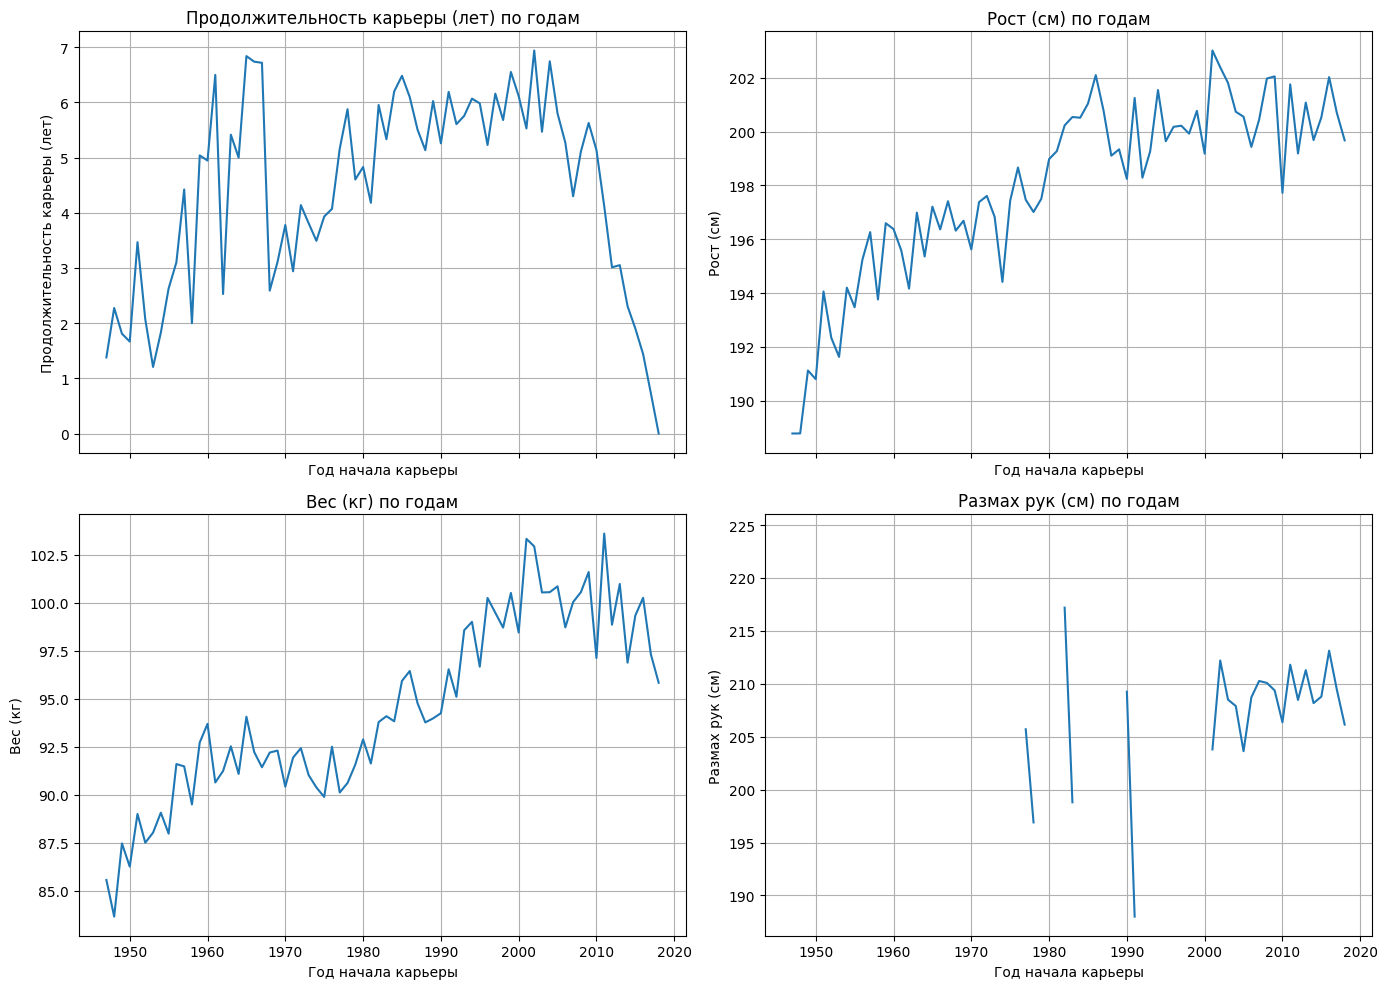

In [62]:
time_stats = nba.groupby('Year Start')[['Career Length','Height','Weight_kg','Wingspan']].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
metrics = [('Career Length','Продолжительность карьеры (лет)'),
           ('Height','Рост (см)'),
           ('Weight_kg','Вес (кг)'),
           ('Wingspan','Размах рук (см)')]
for ax, (col, label) in zip(axes.flat, metrics):
    ax.plot(time_stats.index, time_stats[col], lw=1.5)
    ax.set_xlabel('Год начала карьеры'); ax.set_ylabel(label); ax.set_title(label + ' по годам')
plt.tight_layout()
plt.show()